<a href="https://colab.research.google.com/github/wanttttttingxie/Projects/blob/main/F26_APS1070_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### APS1070 Project 1 --- Basic Principles and Models (6 percent)

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself without proper acknowledgment of the source, including generated code (please refer to the course syllabus). Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Name: Wanting Xie *(here and elsewhere, please replace the underscore with your answer)*

Student ID: 1002155213

##**Marking Scheme:**

This project is worth **6 percent** of your final grade.

Draw a plot or table where necessary to summarize your findings.

**Practice Vectorized coding**: If you need to write a loop in your solution, think about how you can implement the same functionality with vectorized operations. Try to avoid loops as much as possible (in some cases, loops are inevitable).




### How to submit **(HTML + IPYNB)**

1. Download your notebook: `File -> Download .ipynb`

2. Click on the Files icon on the far left menu of Colab

3. Select & upload your `.ipynb` file you just downloaded, and then obtain its path (right click) (you might need to hit the Refresh button before your file shows up)


4. execute the following in a Colab cell:
```
%%shell
jupyter nbconvert --to html /PATH/TO/YOUR/NOTEBOOKFILE.ipynb
```

5. An HTML version of your notebook will appear in the files, so you can download it.

6. Submit **both** <font color='red'>`HTML` and `IPYNB`</font>  files on Quercus for grading.



Ref: https://stackoverflow.com/a/64487858



# Project 1 [6 Marks]
Let's apply the tools we have learned in the tutorial to a new dataset.

We're going to work with the [bodyfat dataset](https://www.openml.org/search?type=data&sort=runs&id=560&status=active). The dataset lists estimates of the percentage of body fat determined by underwater weighing and various body circumference measurements for a number of individuals.


Download it using the cell below:

In [1]:
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt
dataset = fetch_openml(name='bodyfat', version=1, parser="auto")

## Part 1: Getting started [1.5 Marks]
First off, take a look at the `data`, `target` and `feature_names` entries in the `dataset` dictionary. They contain the information we'll be working with here. Then, create a Pandas DataFrame called `df` containing the data and the targets, with the feature names as column headings. If you need help, see [here](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html) for more details on how to achieve this. **[0.25]**

* How many features do we have in this dataset? 14
* Determine the median target value. 19.2
* How many participants have a target value greater than the median target value? 125


The percentage of body fat for an individual can be estimated once body density has been determined. Thus, for this project, we'll disregard the `Density` feature to make the body fat percentage prediction more challenging. In this case, you need to delete the `Density` column from the dataset.

Now add an additional column containing either 0 (if the target value is below the median) or 1 (if the target value is above the median). This will be the new target value to classify the data as the individuals with a body fat percentage below median or the individuals with a body fat percentage above median. **[0.3]**

In [2]:
#TO BE CLEARED
#check dataset dictionary
print(dataset.keys())

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [3]:
#dataframe df with data and targets, with the feaure names as column headings
import pandas as pd

df = pd.DataFrame(dataset['data'], columns=dataset['feature_names'])
df['target'] = dataset['target']

In [4]:
#How many features do we have in this dataset? 14
len(dataset['feature_names'])

14

In [5]:
#Determine the median target value. 19.2
median = df['target'].median()
print(median)

19.2


In [6]:
#How many participants have a target value greater than the median target value?
count = (df['target'] > median).sum()
print(count)

125


In [7]:
# delete the Density column from the dataset
df = df.drop('Density',axis=1)


In [8]:
#Now add an additional column containing either 0 (if the target value is below the median) or 1 (if the target value is above the median).
#new column name = target_class
df['target_class'] = (df['target'] > median).astype(int)

In [9]:
#TO BE CLEARED
#check the new dataframe
df

,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,target,target_class
0,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1,12.3,0
1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2,6.1,0
2,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6,25.3,1
3,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2,10.4,0
4,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7,28.7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,70,134.25,67.00,34.9,89.2,83.6,88.8,49.6,34.8,21.5,25.6,25.7,18.5,11.0,0
248,72,201.00,69.75,40.9,108.5,105.0,104.5,59.6,40.8,23.2,35.2,28.6,20.1,33.6,1
249,72,186.75,66.00,38.9,111.1,111.5,101.7,60.3,37.3,21.5,31.3,27.2,18.0,29.3,1
250,72,190.75,70.50,38.9,108.3,101.3,97.8,56.0,41.6,22.7,30.5,29.4,19.8,26.0,1


### Splitting the data
It is best practice to have a training set (from which there is a rotating validation subset) and a test set. Our aim here is to (eventually) obtain the best accuracy we can on the test set (we'll do all our tuning on the training/validation sets, however.)

**Split the dataset** into a train and a test set **"70:30"**, use **``random_state=0``**. The test set is set aside (untouched) for final evaluation, once hyperparameter optimization is complete. **[0.3]**

**Only Split the dataset once within your notebook.** You should not use the `train_test_split` function more than once, regardless of the random state. Keep this in mind for your future projects as well.

In [10]:
### YOUR CODE HERE ###

#70% training and 30% test data with random_state = 0

from sklearn.model_selection import train_test_split
X = df.drop(columns=['target', 'target_class'])
y = df['target_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)


### Effect of Standardization (Visual)
Use `seaborn.lmplot` ([help here](https://seaborn.pydata.org/generated/seaborn.lmplot.html)) to visualize a few features of the training set. Draw a plot where the x-axis is the *Chest circumference (cm)* i.e. ``Chest``, the y-axis is the *Wrist circumference (cm)* i.e. ``Wrist``, and the color of each datapoint indicates its class.  **[0.3]**

Standardizing the data is often critical in machine learning. Show a plot as above, but standardize the two features. What's different? **why do they look similar?** Based on your observation, what is the advantage of standardization? **[0.35]**




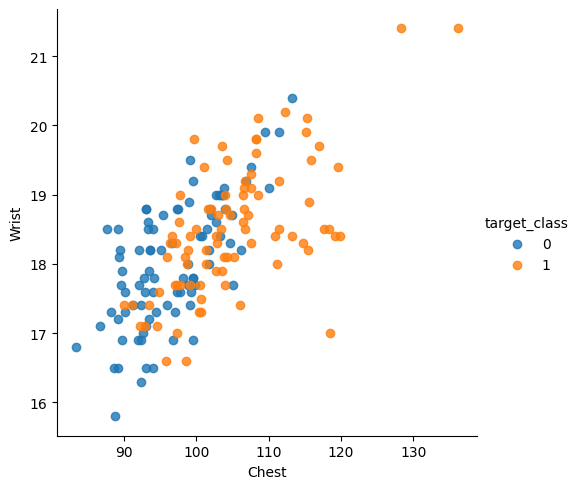

In [11]:
### YOUR CODE HERE ###
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Combine features + labels into one DataFrame
train_df = X_train.copy()
train_df['target_class'] = y_train

# 2. Plot
sns.lmplot(
    data=train_df,
    x='Chest',
    y='Wrist',
    hue='target_class',
    fit_reg=False
)

plt.show()


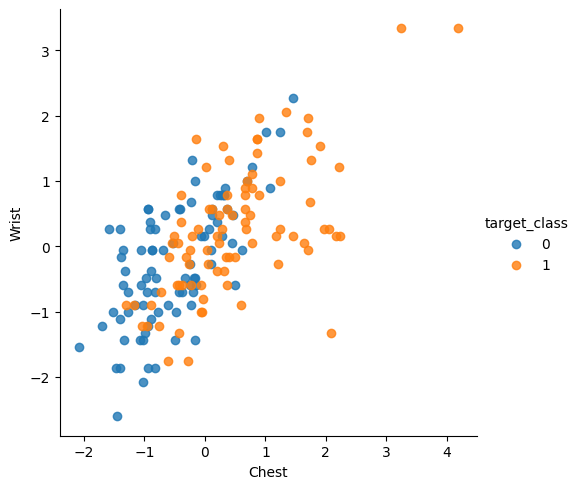

In [12]:
#standardized.
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Copy so we don't overwrite train_df
train_std = train_df.copy()

scaler = StandardScaler()
train_std[['Chest', 'Wrist']] = scaler.fit_transform(train_df[['Chest', 'Wrist']])

# Plot
sns.lmplot(
    data=train_std,
    x='Chest',
    y='Wrist',
    hue='target_class',
    fit_reg=False
)

plt.show()


What's different?
- The axes are different, before the data is standardized, the Chest data is from 85 - 135 and Wrist from 16-21. After standardized, the axes for chest is from -2-4 and for wrist is from -3-4

why do they look similar?
- Standardization is a linear transformation which only shifts and rescales each axis independently, by subtracting the mean and dividing by standard deviation. It does not change the positions of the points and which points are near which. So essentially the pattern of the points is the same, only the units on the axes change.

Based on your observation, what is the advantage of standardization?
- Standardization ensures that all features are on the same scale. Without it, features with larger numeric ranges — such as Chest (85-135) compared to Wrist (16-21) — would disproportionately influence distance-based computations. The larger-range features will drown out the smaller-range features. Standardization removes this bias, allowing each feature to contribute equally. So a one-unit change in Chest is exatly as "large" as a one-unit change in wrist. Distance calculations them weight them fairly.



## Part 2: KNN Classifier without Standardization [1.2 Marks]
Normally, standardizing data is a key step in preparing data for a KNN classifier. However, for educational purposes, let's first try to build a model without standardization. Let's create a KNN classifier to predict whether an individual has a body fat percentage that is less than the median or greater than the median.

Follow these steps:

1.   Train a KNN Classifier using cross-validation on the dataset. Sweep `k` (number of neighbours) from 1 to 100, and show a plot of the mean cross-validation accuracy vs `k`. **[0.6]**
2.   What is the best `k`? What is the highest cross-validation accuracy? **[0.3]**
3. Comment on  which ranges of `k` lead to underfitted or overfitted models (hint: compare training and validation curves!). **[0.3]**



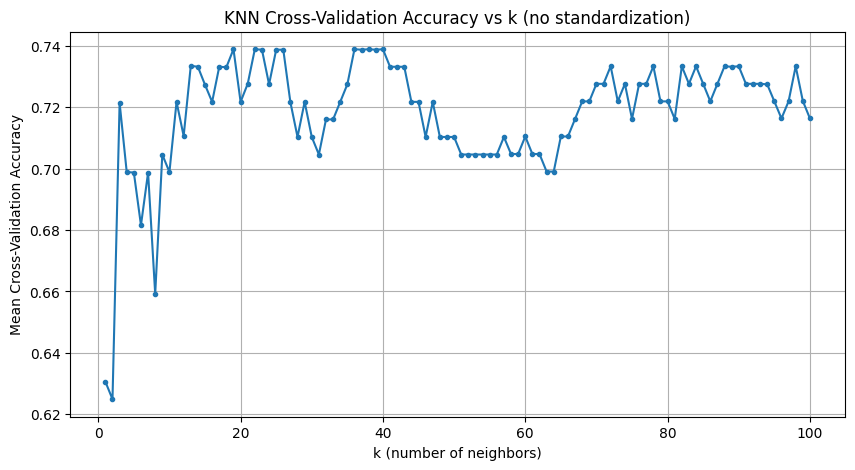

In [13]:
### YOUR CODE HERE ###
#1. Train a KNN Classifier using cross-validation on the dataset. [0.6]
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_values = range(1, 101)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

#plot accuracy vs k

plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, marker='o', markersize=3)
plt.xlabel('k (number of neighbors)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.title('KNN Cross-Validation Accuracy vs k (no standardization)')
plt.grid(True)
plt.show()

In [14]:
#2.What is the best k? What is the highest cross-validation accuracy? [0.3]
best_k = list(k_values)[np.argmax(cv_scores)]
best_score = max(cv_scores)

print(f"Best k: {best_k}")
print(f"Highest CV accuracy: {best_score:.4f}")

Best k: 19
Highest CV accuracy: 0.7389


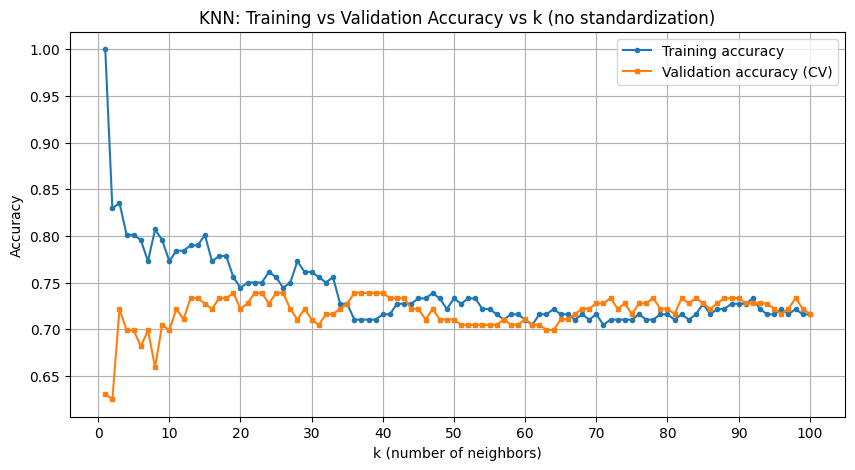

In [15]:
#3.Comment on which ranges of k lead to underfitted or overfitted models (hint: compare training and validation curves!). [0.3]

k_values = range(1, 101)
train_scores = []
val_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    # Validation: 5-fold CV (what you already did)
    val = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy').mean()
    val_scores.append(val)

    # Training: fit on all of X_train, score on X_train
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_scores, label='Training accuracy', marker='o', markersize=3)
plt.plot(k_values, val_scores,   label='Validation accuracy (CV)', marker='s', markersize=3)
plt.xticks(np.arange(0, 101, 10))
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN: Training vs Validation Accuracy vs k (no standardization)')
plt.legend()
plt.grid(True)
plt.show()

3. (continues) Looking at the above graph, comparing training accuracy curve and validation accuracy curve.

- Small k (roughly k ≤ 10): overfitting. Training accuracy is very high (near 1.0 at k=1) while validation accuracy is much lower. The large gap between the two curves shows the model has memorized the training data and does not generalize.

- Medium k (around the peak, k ≈ 15–25): good fit. The training and validation curves are closest together, and validation accuracy reaches its maximum at k = 19 with a cross-validation accuracy of 0.7389.

- Large k (roughly k ≥ 70): underfitting. Both curves converge at a low level (~0.72). With so many neighbors, predictions are dominated by the majority class, and the model is too smooth to capture the data's structure.

## Part 3: Feature Selection [1.8 Marks]
In this part, we aim to investigate the importance of each feature on the final classification accuracy.
If we want to try every possible combination of features, we would have to test  $2^F$ different cases,  where F is the number of features, and in each case, we have to do a hyperparameter search (finding K, in KNN using cross-validation). That will take days!.

To find more important features we will use a decision tree. based on a decision tree we can compute feature importance that is a metric for our feature selection (code is provided below).

You can use [this link](https://machinelearningmastery.com/calculate-feature-importance-with-python/
) to get familiar with extracting the feature impotance order of machine learning algorithms in Python.

After we identified and removed the least important feature and evaluated a new KNN model on the new set of features, if the stop conditions (see step 7 below) are not met, we need to repeat the process and remove another feature.


Design a function ( `Feature_selector`) that accepts your dataset (X_train , y_train) and a threshold as inputs and: **[0.6]**
1. Fits a decision tree classifier on the training set.

2. Extracts the feature importance order of the decision tree model.

3. Removes the least important feature based on step 2.
4. Then, a KNN model is trained on the remaining features. The number of neighbors (`k`) for each KNN model should be tuned using a 5-fold cross-validation.
5. Store the best `mean cross-validation` score and the corresponding `k` (number of neighbours) value in two lists.
6. Go back to step 3 and follow all the steps until you meet the stop condition (step 7).

7. We will stop this process when (1) there is only one feature left, or (2) our cross-validation accuracy is dropped significantly compared to a model that uses all the features. In this function, we accept a threshold as an input argument. For example, if threshold=0.95 we do not continue removing features if our mean cross-validation accuracy after tuning `k` is bellow **0.95 $\times$ Full Feature cross-validation accuracy**.

8. Your function returns the list of removed features, and the corresponding mean cross-validation accuracy and `k` value when a feature was removed.

* Visualize your results by plotting the mean cross-validation accuracy (with a tuned `k` on y axis) vs. the number of features (x axis). This plot describes: what is the best cv score with 1 feature, 2 features, 3 features ... and all the features. **[0.3]**

* Plot the best value of `k` (y-axis) vs. the number of features. This plot explains the trend of number of neighbours with respect to the number of features.  **[0.3]**

* State what is the number of essential features for classification and justify your answer. **[0.6]**
  
  









You can use the following piece of code to start training a decision tree classifier and obtain its feature importance order.
```
from sklearn import tree
dt = tree.DecisionTreeClassifier()
dt.fit(X_train,y_train)
importance = dt.feature_importances_
```


In [18]:
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

def best_knn_cv(X, y, k_range=range(1, 101), cv=5): #helper function to find the best k and its CV score for a given feature set
    best_score = 0
    best_k = 1
    for k in k_range:
        knn = KNeighborsClassifier(n_neighbors=k)
        score = cross_val_score(knn, X, y, cv=cv, scoring='accuracy').mean()
        if score > best_score:
            best_score = score
            best_k = k
    return best_score, best_k

def Feature_selector(X_train, y_train, tr=0.95):
    # (setup — baseline + lists)
    baseline_score, _ = best_knn_cv(X_train, y_train)
    current_features = list(X_train.columns)
    removed_features = []
    cv_scores = []
    best_ks = []

    # (loop guard + steps 6 & 7)
    while len(current_features) > 1:
        # Step 1: fit decision tree
        dt = tree.DecisionTreeClassifier(random_state=0)
        dt.fit(X_train[current_features], y_train)

        # Step 2: extract importance order
        pairs = list(zip(current_features, dt.feature_importances_))
        pairs.sort(key=lambda p: p[1])

        # Step 3: remove least important
        least_important = pairs[0][0]
        current_features.remove(least_important)
        removed_features.append(least_important)

        # Step 4: train KNN with tuned k (5-fold CV)
        score, best_k = best_knn_cv(X_train[current_features], y_train)

        # Step 5: store score and k
        cv_scores.append(score)
        best_ks.append(best_k)

        # Step 7: stop condition
        if score < tr * baseline_score:
            break

    # Step 8: return the lists
    return removed_features, cv_scores, best_ks

In [19]:
removed, scores, ks = Feature_selector(X_train, y_train)

print("Removed features (in order):", removed)
print("CV scores:                  ", [f"{s:.4f}" for s in scores])
print("Best k per step:            ", ks)

Removed features (in order): ['Hip', 'Age', 'Ankle', 'Neck', 'Biceps', 'Height', 'Forearm', 'Wrist', 'Thigh', 'Chest', 'Knee', 'Weight']
CV scores:                   ['0.7500', '0.7837', '0.7837', '0.7781', '0.7840', '0.7841', '0.7841', '0.7840', '0.7671', '0.7783', '0.7954', '0.7898']
Best k per step:             [23, 11, 11, 11, 14, 21, 21, 12, 12, 7, 7, 47]


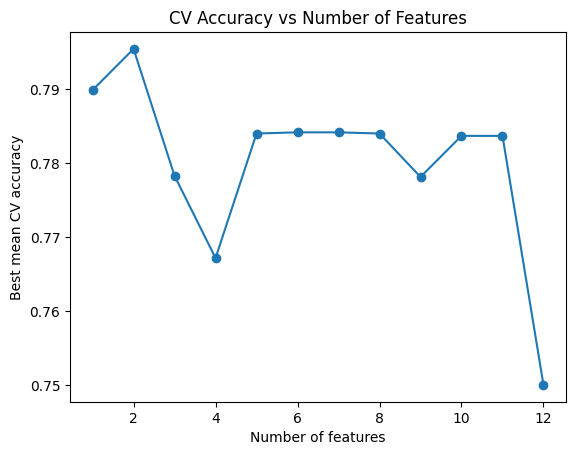

In [21]:
#Visualize your results by plotting the mean cross-validation accuracy (with a tuned k on y axis)
#vs. the number of features (x axis). This plot describes:
#what is the best cv score with 1 feature, 2 features, 3 features ... and all the features. [0.3]

num_features = [X_train.shape[1] - i for i in range(1, len(scores) + 1)]
plt.plot(num_features, scores, marker='o')
plt.xlabel('Number of features')
plt.ylabel('Best mean CV accuracy')
plt.title('CV Accuracy vs Number of Features')
plt.show()



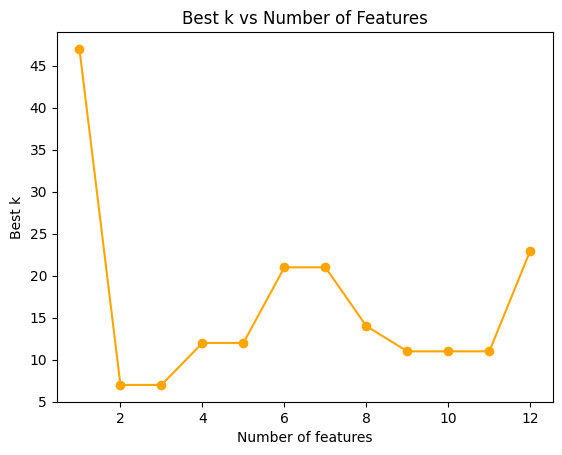

In [22]:
# Plot the best value of k (y-axis) vs. the number of features.
#This plot explains the trend of number of neighbours with respect to the number of features. [0.3]
plt.plot(num_features, ks, marker='o', color='orange')
plt.xlabel('Number of features')
plt.ylabel('Best k')
plt.title('Best k vs Number of Features')
plt.show()

State what is the number of essential features for classification and justify your answer. [0.6]

- Approximately 2 essential features are needed for classification. The CV-accuracy curve peaks at 2 features (≈0.795), and remains essentially flat (≈0.783–0.784) up to about 8 features — meaning that adding more features beyond a small subset does not improve performance. In fact, using all 12 features produces the worst accuracy on the plot (0.750), and removing the very first feature (12→11) gives the largest jump (+3.3%). This shows that most features are redundant or noisy for KNN; the essential classification signal is concentrated in a very small subset of the original variables. Therefore, ~2 features are sufficient.

## Part 4: Standardization [0.6 Marks]

Standardizing the data usually means scaling our data to have a mean of zero and a standard deviation of one.

**Note:** When we standardize a dataset, do we care if the data points are in our training set or test set? Yes! The training set is available for us to train a model - we can use it however we want. The test set, however, represents a subset of data that is not available for us during training. For example, the test set can represent the data that someone who bought our model would use to see how the model performs (which they are not willing to share with us).
Therefore, we cannot compute the mean or standard deviation of the whole dataset to standardize it - we can only calculate the mean and standard deviation of the training set. However, when we sell a model to someone, we can say what our scalers (mean and standard deviation of our training set) was. They can scale their data (test set) with our training set's mean and standard deviation. Of course, there is no guarantee that the test set would have a mean of zero and a standard deviation of one, but it should work fine.

**To summarize: We fit the StandardScaler only on the training set. We transform both training and test sets with that scaler.**

1. Standardize the training  and test data ([Help](https://scikit-learn.org/stable/modules/preprocessing.html))

2. Call your ``Feature_selector`` function on the standardized training data with a threshold of 95\%.
 * Plot the Cross validation accuracy when we have the standardized data (this part) and the original training data (last part) vs. the Number of features in a single plot (to compare them easily).

3. Discuss how standardization (helped/hurt) your model and its performance? Discuss which cases lead to a higher cross validation accuracy (how many features? which features? What K?)


In [ ]:
### YOUR CODE HERE ###

## Part 5: Decision Tree Classifier [0.6 Mark]

Train a decision tree classifier on the standardized dataset (read the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) and check the example there.) Tune the `max_depth` and `min_samples_split` parameters of the tree using cross-validation (CV).
 * Compare the decision tree's performance (mean CV score) with KNN, both using all the features.


In [ ]:
### YOUR CODE HERE ###

## Part 6: Test Data [0.3 Mark]

Now that you've created several models, pick your best one (highest CV accuracy) and apply it to the test dataset you had initially set aside. Discuss your results.

In [ ]:
### YOUR CODE HERE ###

References:

https://towardsdatascience.com/decision-trees-in-machine-learning-641b9c4e8052

https://www.analyticsvidhya.com/blog/2021/02/machine-learning-101-decision-tree-algorithm-for-classification/